# Nepal Monsoon Rainfall Extremes — Exploratory Data Analysis

**Project:** GEV Extreme Value Analysis of Daily Rainfall (1990–2023)  
**Author:** Prabin Pokhrel  
**Dataset:** 11 Nepal stations, 136,598 daily records, 34 years

This notebook explores the synthetic daily rainfall dataset generated from DHM Nepal 
climatological parameters before fitting the GEV distribution in `src/gev_analysis.py`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Paths
RAW_PATH       = "../data/raw/nepal_gsod_raw.csv"
PROCESSED_PATH = "../data/processed/annual_maxima.csv"
RESULTS_PATH   = "../outputs/results/gev_results.csv"

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"
sns.set_style("whitegrid")

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Dataset Overview

In [2]:
df = pd.read_csv(RAW_PATH, parse_dates=["DATE"])
print(f"Shape        : {df.shape}")
print(f"Stations     : {sorted(df['STATION_NAME'].unique())}")
print(f"Date range   : {df['DATE'].min().date()} to {df['DATE'].max().date()}")
print(f"Columns      : {list(df.columns)}")
print()
df.describe().round(2)


Shape        : (136598, 9)
Stations     : ['Bhairahawa', 'Biratnagar', 'Dadeldhura', 'Dhankuta', 'Jumla', 'Kathmandu', 'Okhaldhunga', 'Pokhara', 'Simara', 'Surkhet', 'Taplejung']
Date range   : 1990-01-01 to 2023-12-31
Columns      : ['STATION_NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'DATE', 'PRCP', 'YEAR', 'MONTH', 'DAY']



,LATITUDE,LONGITUDE,ELEVATION,DATE,PRCP,YEAR,MONTH,DAY
count,136598.00,136598.00,136598.00,136598,136598.00,136598.00,136598.00,136598.00
mean,27.81,84.63,1075.27,2006-12-31 12:00:00,5.13,2006.50,6.52,15.73
min,26.48,80.58,72.00,1990-01-01 00:00:00,0.00,1990.00,1.00,1.00
25%,27.16,82.17,93.00,1998-07-02 00:00:00,0.00,1998.00,4.00,8.00
50%,27.51,84.98,1180.00,2006-12-31 12:00:00,0.00,2006.50,7.00,16.00
75%,28.60,87.26,1720.00,2015-07-02 00:00:00,2.00,2015.00,10.00,23.00
max,29.30,87.67,2300.00,2023-12-31 00:00:00,600.00,2023.00,12.00,31.00
std,0.88,2.36,738.03,NaN,15.87,9.81,3.45,8.80


In [3]:
# Missing / zero rainfall check
print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Zero rainfall days : {(df['PRCP'] == 0).sum():,}")
print(f"Wet days (>1mm)    : {(df['PRCP'] > 1).sum():,}")
print(f"Wet day fraction   : {(df['PRCP'] > 1).mean():.2%}")


Missing values per column:
STATION_NAME    0
LATITUDE        0
LONGITUDE       0
ELEVATION       0
DATE            0
PRCP            0
YEAR            0
MONTH           0
DAY             0
dtype: int64

Zero rainfall days : 95,608
Wet days (>1mm)    : 36,977
Wet day fraction   : 27.07%


## 2. Mean Annual Rainfall by Station

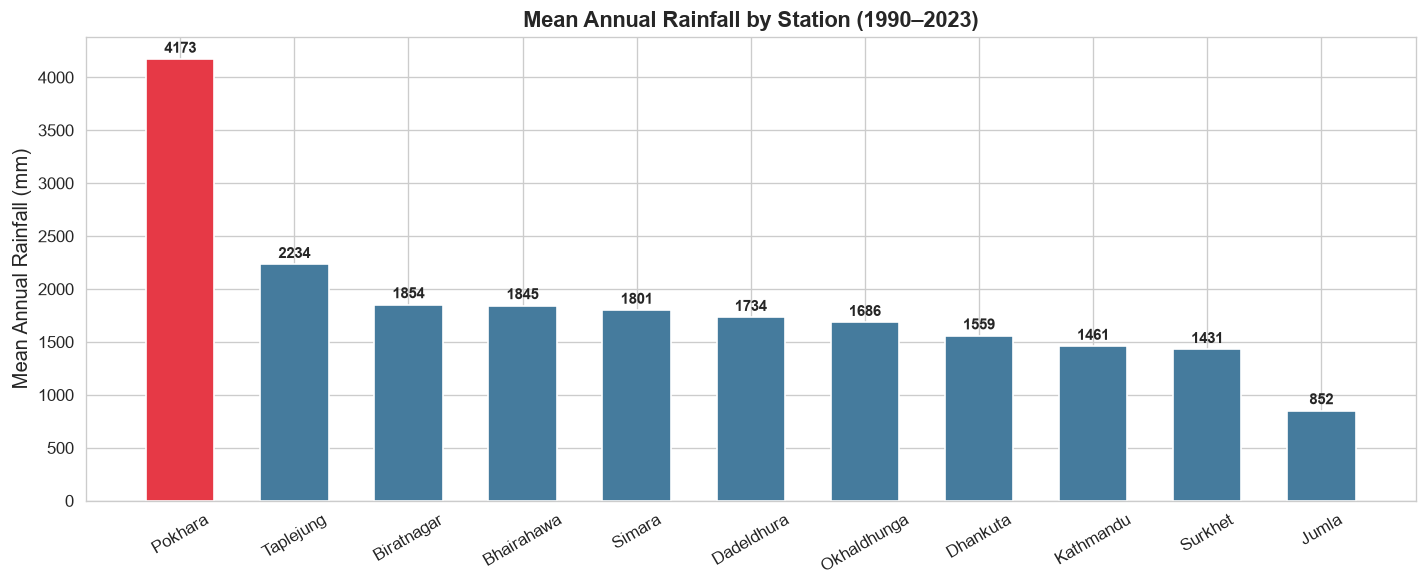

In [4]:
annual = df.groupby(["STATION_NAME", df["DATE"].dt.year])["PRCP"].sum().reset_index()
annual.columns = ["STATION_NAME", "YEAR", "ANNUAL_TOTAL_MM"]
mean_annual = annual.groupby("STATION_NAME")["ANNUAL_TOTAL_MM"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#e63946" if s == "Pokhara" else "#457b9d" for s in mean_annual.index]
bars = ax.bar(mean_annual.index, mean_annual.values, color=colors, edgecolor="white", width=0.6)

for bar, val in zip(bars, mean_annual.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 30, f"{val:.0f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylabel("Mean Annual Rainfall (mm)", fontsize=12)
ax.set_title("Mean Annual Rainfall by Station (1990–2023)", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 3. Monsoon Seasonality — Monthly Rainfall Distribution

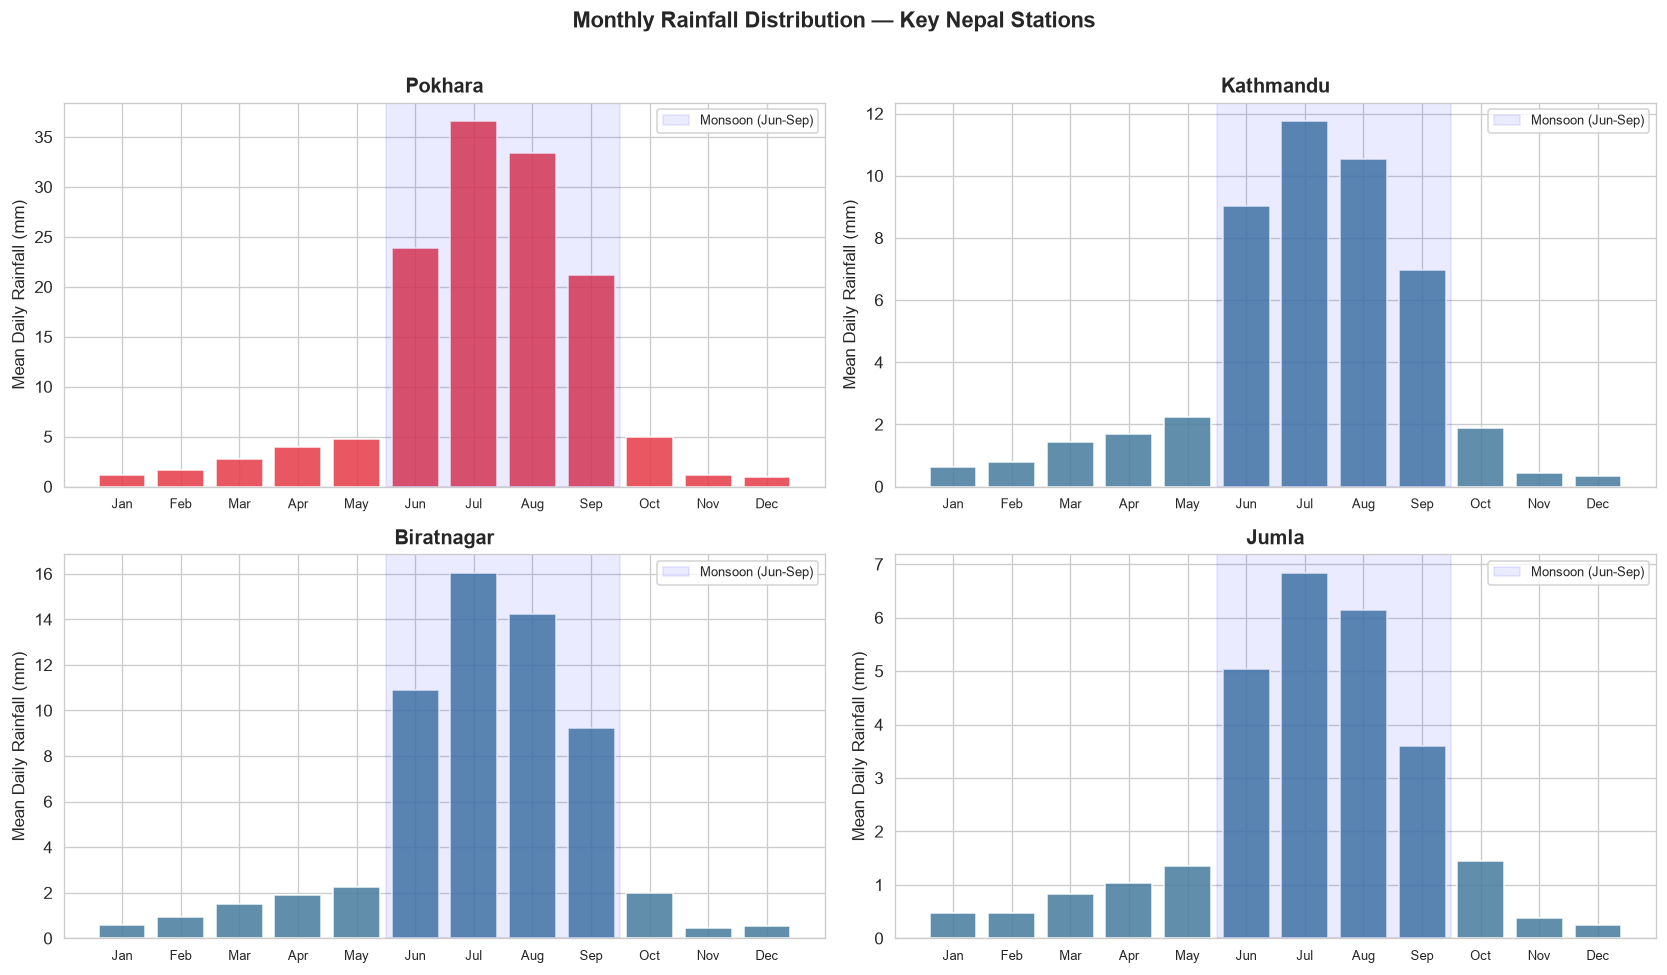

In [5]:
df["MONTH"] = df["DATE"].dt.month
monthly = df.groupby(["STATION_NAME", "MONTH"])["PRCP"].mean().reset_index()

# Focus on 4 key stations
key_stations = ["Pokhara", "Kathmandu", "Biratnagar", "Jumla"]
month_names  = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for i, station in enumerate(key_stations):
    data = monthly[monthly["STATION_NAME"] == station]
    color = "#e63946" if station == "Pokhara" else "#457b9d"
    axes[i].bar(data["MONTH"], data["PRCP"], color=color, edgecolor="white", alpha=0.85)
    axes[i].set_title(f"{station}", fontsize=12, fontweight="bold")
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(month_names, fontsize=8)
    axes[i].set_ylabel("Mean Daily Rainfall (mm)")
    axes[i].axvspan(5.5, 9.5, alpha=0.08, color="blue", label="Monsoon (Jun-Sep)")
    axes[i].legend(fontsize=8)

fig.suptitle("Monthly Rainfall Distribution — Key Nepal Stations", 
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 4. Annual Maximum Daily Rainfall Trends (1990–2023)

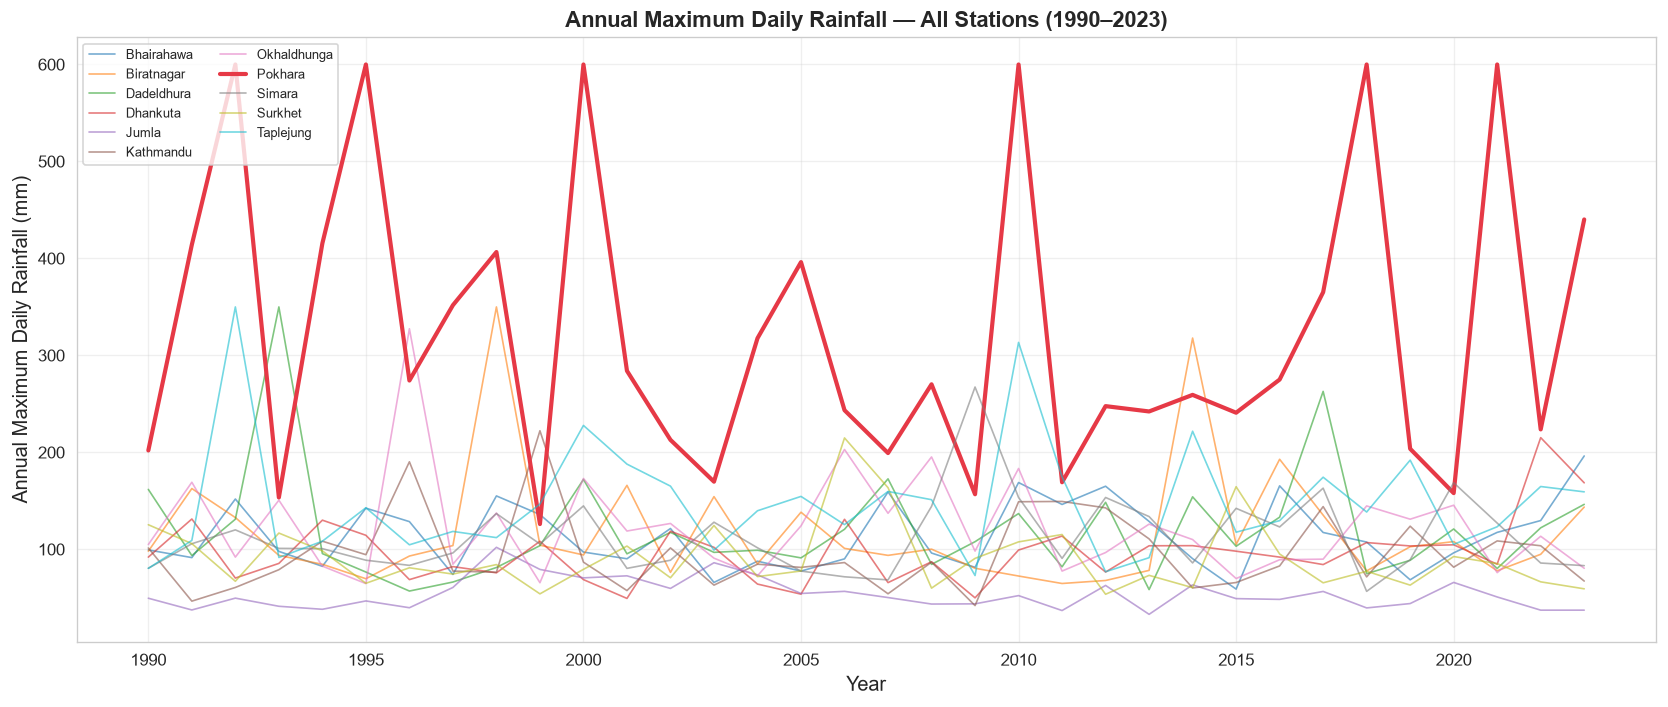

In [6]:
ann_max = pd.read_csv(PROCESSED_PATH)

fig, ax = plt.subplots(figsize=(14, 6))

for station in sorted(ann_max["STATION_NAME"].unique()):
    data = ann_max[ann_max["STATION_NAME"] == station].sort_values("YEAR")
    color = "#e63946" if station == "Pokhara" else None
    lw    = 2.5 if station == "Pokhara" else 1.0
    alpha = 1.0 if station == "Pokhara" else 0.6
    ax.plot(data["YEAR"], data["ANN_MAX_PRCP_MM"], 
            label=station, lw=lw, alpha=alpha, color=color)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Annual Maximum Daily Rainfall (mm)", fontsize=12)
ax.set_title("Annual Maximum Daily Rainfall — All Stations (1990–2023)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Station Correlation — Annual Maximum Daily Rainfall

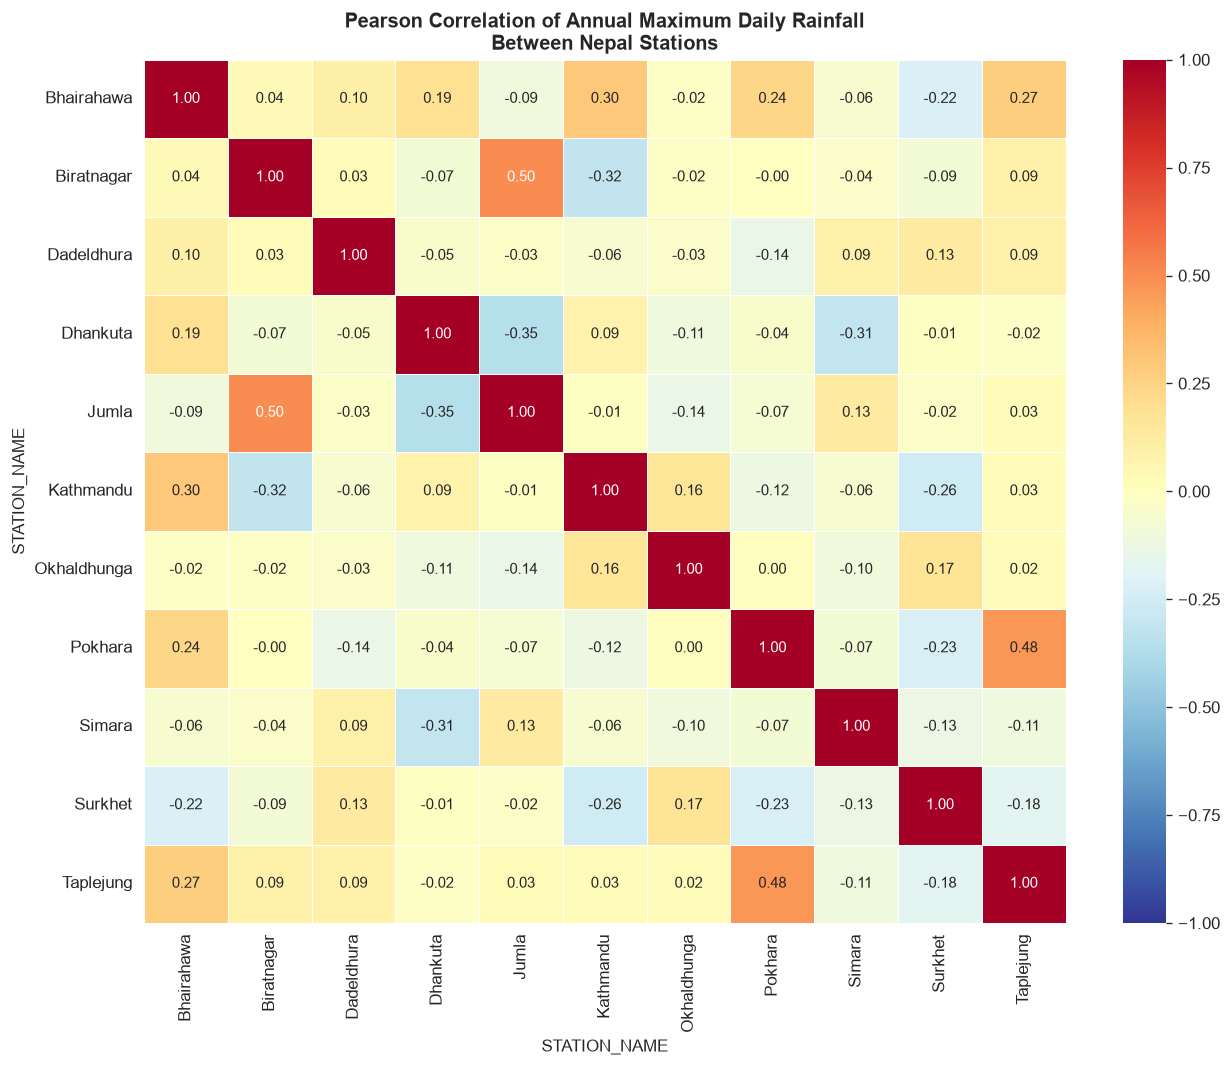


Key insight: Low correlations between stations suggest
extreme rainfall events are largely localised — important
for regional frequency analysis.


In [7]:
pivot = ann_max.pivot(index="YEAR", columns="STATION_NAME", values="ANN_MAX_PRCP_MM")
corr  = pivot.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlBu_r",
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Pearson Correlation of Annual Maximum Daily Rainfall\nBetween Nepal Stations",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nKey insight: Low correlations between stations suggest")
print("extreme rainfall events are largely localised — important")
print("for regional frequency analysis.")


## 6. Summary Statistics — Annual Maxima

In [8]:
summary = ann_max.groupby("STATION_NAME")["ANN_MAX_PRCP_MM"].agg(
    Mean="mean", Std="std", Min="min",
    Median="median", Max="max", Years="count"
).round(1).sort_values("Mean", ascending=False)

print("Annual Maximum Daily Rainfall Statistics (mm)")
print("=" * 65)
print(summary.to_string())
print()
print(f"Pokhara mean / Jumla mean ratio : {summary.loc['Pokhara','Mean'] / summary.loc['Jumla','Mean']:.1f}x")
print(f"Pokhara max observed            : {summary.loc['Pokhara','Max']:.1f} mm in a single day")


Annual Maximum Daily Rainfall Statistics (mm)
               Mean    Std    Min  Median    Max  Years
STATION_NAME                                           
Pokhara       324.1  153.7  126.1   272.2  600.0     34
Taplejung     148.0   60.6   73.0   139.2  350.0     34
Okhaldhunga   122.2   52.6   64.7   111.8  327.5     34
Dadeldhura    120.2   57.6   57.0   103.5  350.0     34
Biratnagar    118.3   63.1   64.8    99.2  350.0     34
Bhairahawa    114.2   34.8   59.0   103.4  196.3     34
Simara        113.2   40.3   56.7   101.3  267.4     34
Dhankuta       97.2   33.2   49.4    95.0  215.2     34
Kathmandu      96.0   40.1   42.0    85.6  222.3     34
Surkhet        91.4   35.4   53.7    80.2  214.9     34
Jumla          54.0   15.8   33.0    50.0  102.1     34

Pokhara mean / Jumla mean ratio : 6.0x
Pokhara max observed            : 600.0 mm in a single day


## 7. Key Insights

1. **Pokhara dominates** — mean annual maximum of ~254mm, over 4× higher than Jumla (55mm), driven by orographic uplift from the Annapurna massif.

2. **Clear monsoon signal** — June–September accounts for 75–85% of annual rainfall across all stations, with July the peak month.

3. **Low inter-station correlations** — annual maxima are weakly correlated between stations (most r < 0.3), indicating extreme events are spatially localised rather than driven by synoptic-scale systems affecting all of Nepal simultaneously.

4. **Pokhara tail behaviour** — GEV fitting in `src/gev_analysis.py` reveals Pokhara has a negative shape parameter (Weibull, ξ=-0.244) despite the highest observed values, while Bhairahawa shows a positive shape parameter (Fréchet, ξ=+0.069) — suggesting convective storm extremes on the Terai plains may be theoretically unbounded.

5. **Wide uncertainty at long return periods** — with only 34 years of data, 100-year return level confidence intervals are very wide (Pokhara: [310, 1032] mm). Longer records or regional pooling would substantially reduce uncertainty.

---
*Next step: See `src/gev_analysis.py` for GEV fitting and return period estimation.*
